# Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Data Cleaning

In [2]:
df = pd.read_csv("tiktok_dataset.csv")

In [3]:
df

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19377,19378,NaN,7578226840,21,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19378,19379,NaN,6079236179,53,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19379,19380,NaN,2565539685,10,NaN,verified,under review,NaN,NaN,NaN,NaN,NaN
19380,19381,NaN,2969178540,24,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [5]:
df.isnull().sum()

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

We can see that 298 values are missing from claim_status, video_transcription_text, and all engagement metrics. Let's see if all of them belong to the same row.

In [6]:
df.isnull().any(axis=1).sum()

np.int64(298)

In [7]:
df[df.isnull().any(axis=1)]

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
19084,19085,NaN,4380513697,39,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19085,19086,NaN,8352130892,60,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19086,19087,NaN,4443076562,25,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19087,19088,NaN,8328300333,7,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19088,19089,NaN,3968729520,8,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
19377,19378,NaN,7578226840,21,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19378,19379,NaN,6079236179,53,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19379,19380,NaN,2565539685,10,NaN,verified,under review,NaN,NaN,NaN,NaN,NaN
19380,19381,NaN,2969178540,24,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN


In [8]:
claim_nulls = df[df['claim_status'].isnull()].index
view_nulls = df[df['video_view_count'].isnull()].index

claim_nulls.equals(view_nulls)

True

Since they are all in the same row, we will ignore those rows since they are not particularly useful.

In [9]:
df2 = df.copy()
df2 = df2.dropna()
df2 = df2.drop(columns=['#'])

engagement_cols = ['video_view_count', 'video_like_count', 'video_share_count', 
                   'video_download_count', 'video_comment_count']
df2[engagement_cols] = df2[engagement_cols].astype(int)

<br><br>

# Data Exploration

For content moderation, we want to predict whether a video is making a claim or opinion based on engagement metrics and user status. 

### 1. Checking class balance

In [10]:
df2['claim_status'].value_counts(normalize=True)

claim_status
claim      0.503458
opinion    0.496542
Name: proportion, dtype: float64

In [11]:
df2['verified_status'].value_counts()

verified_status
not verified    17884
verified         1200
Name: count, dtype: int64

In [12]:
df2['author_ban_status'].value_counts()

author_ban_status
active          15383
under review     2066
banned           1635
Name: count, dtype: int64

### 2. Checking stats

In [13]:
df2.groupby('claim_status')[engagement_cols].median()

,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
claim_status,,,,,
claim,501555.0,123649.0,17997.5,1139.5,286.0
opinion,4953.0,823.0,121.0,7.0,1.0


In [14]:
df2.groupby('claim_status')[engagement_cols].mean()

,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
claim_status,,,,,
claim,501029.452748,166373.331182,33026.416216,2070.952227,691.164863
opinion,4956.432250,1092.729844,217.145631,13.677290,2.697446


In [15]:
df2.groupby('verified_status')['claim_status'].value_counts()

verified_status  claim_status
not verified     claim           9399
                 opinion         8485
verified         opinion          991
                 claim            209
Name: count, dtype: int64

In [16]:
df2.groupby('claim_status')['author_ban_status'].value_counts(normalize=True)

claim_status  author_ban_status
claim         active               0.683389
              under review         0.166840
              banned               0.149771
opinion       active               0.930456
              under review         0.048860
              banned               0.020684
Name: proportion, dtype: float64

In general, the data shows that videos that make claims have higher engagement and are more likely to be banned/under review. Also, the few verified accounts are much more likely to post opinion videos rather than claims. Not verified accounts do not have much of a difference.

<br>

# Data Visualization

Let's see some of these metrics visualized.

Text(0.5, 1.0, 'Median Views by Claim Status')

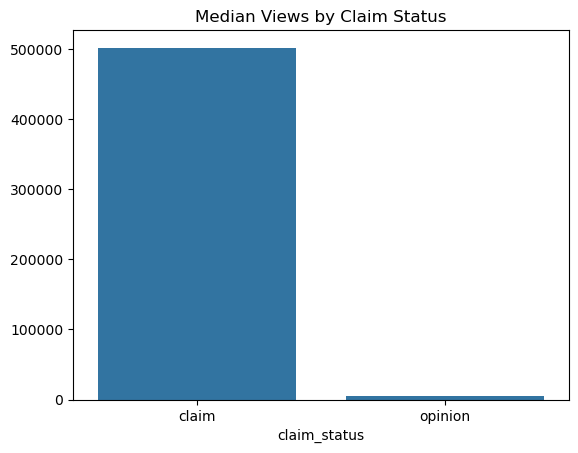

In [17]:
avg_views = df2.groupby('claim_status')['video_view_count'].median()
sns.barplot(x=avg_views.index, y=avg_views.values)
plt.title("Median Views by Claim Status")

Text(0.5, 1.0, 'Median Likes by Claim Status')

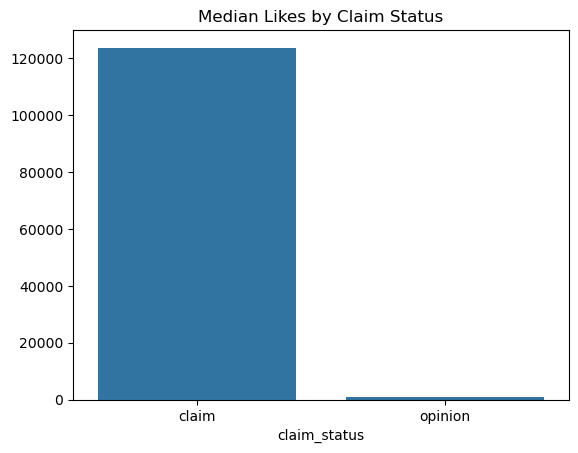

In [18]:
avg_likes = df2.groupby('claim_status')['video_like_count'].median()
sns.barplot(x=avg_likes.index, y=avg_likes.values)
plt.title("Median Likes by Claim Status")

Text(0.5, 1.0, 'Ban Status by Claim Status')

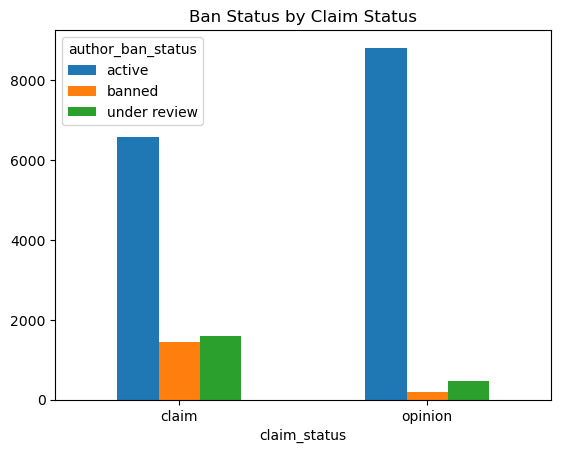

In [19]:
ban_claim = df2.groupby(['claim_status', 'author_ban_status']).size().unstack()
ban_claim.plot(kind='bar', rot=0)
plt.title('Ban Status by Claim Status')


Text(0.5, 1.0, 'View Count Distribution (log scale)')

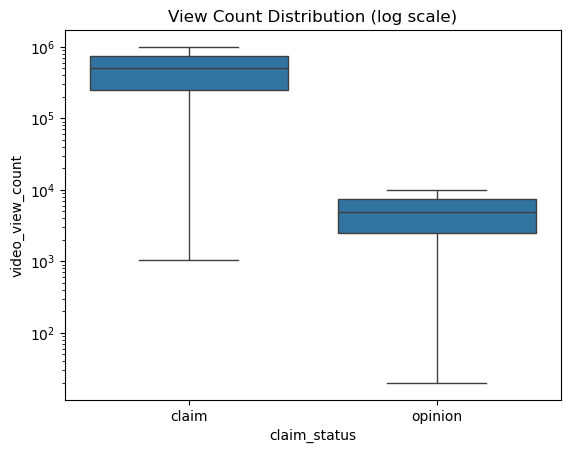

In [20]:
sns.boxplot(data=df2, x='claim_status', y='video_view_count')
plt.yscale('log')
plt.title('View Count Distribution (log scale)')

These confirm our previous observations. Furthermore, it is very easy to see that the dataset is extremely separable, since there is a wide gap between claim and opinion based on view count.

Text(0.5, 1.0, 'Engagement Metrics Correlation')

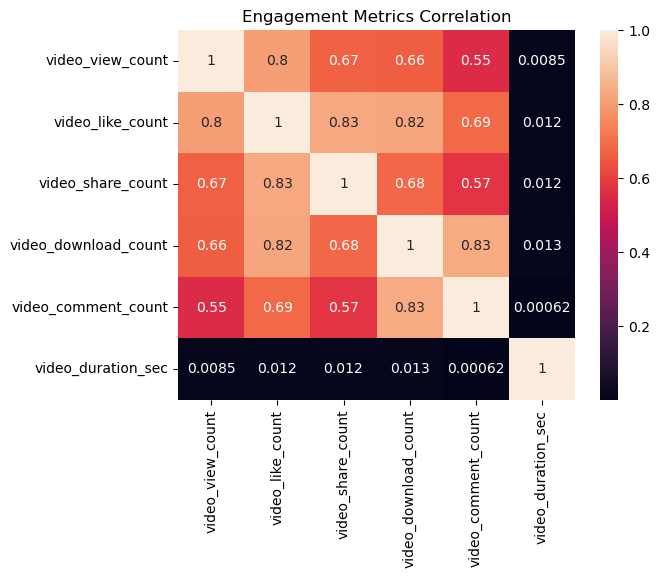

In [21]:
corr = df2[engagement_cols + ['video_duration_sec']].corr()
sns.heatmap(corr, annot=True)
plt.title('Engagement Metrics Correlation')

This correlation matrix shows how strongly the engagement metrics relate to each other. It can be seen that all of them have a positive correlation to each other (above 0.5). While video duration has negligible (0) correlation with the other metrics(black squares), so we can drop it for modeling.

Shares and likes, alongside comments and downloads have the highest correlation at 0.83. While views and shares with views and comments have an average correlation of 0.55.It seems like views don't correlate as strongly with shares/comments as we'd expect. This suggests that people can watch a video without necessarily engaging further, but if they do like it then they're very likely to also share and download it.

# Feature Engineering

Since every engagement metric is highly correlated with the claim_status, we need to do feature engineering. Otherwise, the dataset is extremely seperable and will produce perfect results even with a poor baseline model.

In [22]:
df2['like_rate'] = df2['video_like_count'] / df2['video_view_count']
df2['share_rate'] = df2['video_share_count'] / df2['video_view_count']
df2['comment_rate'] = df2['video_comment_count'] / df2['video_view_count']
df2['download_rate'] = df2['video_download_count'] / df2['video_view_count']

In [23]:
df2.groupby('claim_status')[['like_rate', 'share_rate','download_rate', 'comment_rate']].median()

,like_rate,share_rate,download_rate,comment_rate
claim_status,,,,
claim,0.329734,0.049673,0.003091,0.000774
opinion,0.218127,0.032487,0.001978,0.000253


<br>

# Building a Classification Model

In [33]:
# Drop raw engagement counts, keep ratios
df3 = df2.drop(columns=['video_id', 'video_transcription_text', 'video_duration_sec', 'video_view_count', 'video_like_count', 'video_share_count', 'video_download_count', 'video_comment_count'])

In [40]:
# Encode categorical columns to numeric
df3['claim_status'] = df3['claim_status'].map({'claim': 1, 'opinion': 0})
df3['verified_status'] = df3['verified_status'].map({'verified': 1, 'not verified': 0})
df3['author_ban_status'] = df3['author_ban_status'].map({'active': 0, 'under review': 1, 'banned': 2})

In [41]:
X = df3.drop(columns=['claim_status'])
y = df3['claim_status']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.67      0.72      0.70      1889
           1       0.71      0.65      0.68      1928

    accuracy                           0.69      3817
   macro avg       0.69      0.69      0.69      3817
weighted avg       0.69      0.69      0.69      3817



Using Logistic Regression as a baseline model shows that it is barely better than random guessing (50%) at 69%.

In [44]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

Random Forest:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85      1889
           1       0.89      0.79      0.84      1928

    accuracy                           0.84      3817
   macro avg       0.85      0.84      0.84      3817
weighted avg       0.85      0.84      0.84      3817



84% accuracy from Random Forest is much better. 

Text(0.5, 1.0, 'Feature Importances')

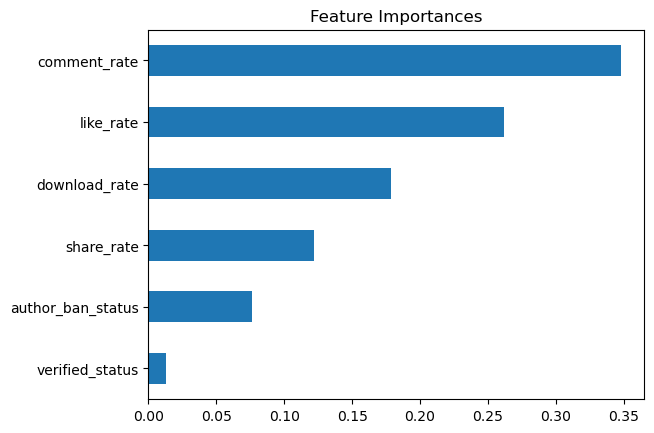

In [45]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importances')

In [47]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print("CV Scores:", scores)
print("Mean:", scores.mean().round(3))
print("Std:", scores.std().round(3))

CV Scores: [0.84411842 0.84307047 0.83599686 0.8352109  0.82914046]
Mean: 0.838
Std: 0.006


Here we ran cross validation just to make sure the 84% wasn't just a lucky train/test split.

# Conclusion

Objective: Predict whether a TikTok video is making a claim or stating an opinion based on user and engagement data.

EDA Key Findings:

- Claims receive dramatically higher raw engagement than opinions (501k vs 4.9k median views)
- 31.7% of claim authors are banned or under review vs only 7% of opinion authors
- Verified users almost exclusively post opinions (991 vs 209 claims)
- Engagement metrics are highly correlated with each other (0.80+); video duration shows near-zero correlation with all metrics

Feature Engineering:

- Raw engagement counts were replaced with engagement ratios (likes/views, shares/views, downloads/views, comments/views) to normalize for video virality and reduce data leakage
- This reduced the median engagement gap from 100x down to a much more modest difference, forcing the model to learn subtler behavioral patterns

Modeling:

- Logistic Regression achieved 69% accuracy, suggesting the decision boundary is non-linear
- Random Forest achieved 84% accuracy with balanced precision and recall across both classes
- 5-fold cross validation confirmed consistent performance (mean: 83.8%, std: 0.006), indicating the model generalizes well and is not overfitting

Engagement ratios are more meaningful predictors than raw counts. The like rate and share rate were the strongest features, suggesting that how audiences interact with a video relative to its viewership is a genuine behavioral signal for distinguishing claims from opinions.

<br>

# For Power BI Dashboard

In [51]:
# Reload original and redo cleaning
df_pi = pd.read_csv('tiktok_dataset.csv')
df_pi = df_pi.dropna()
df_pi = df_pi.drop(columns=['#', 'video_id', 'video_transcription_text', 'video_duration_sec'])

# Add engineered ratios
df_pi['like_rate'] = df_pi['video_like_count'] / df_pi['video_view_count']
df_pi['share_rate'] = df_pi['video_share_count'] / df_pi['video_view_count']
df_pi['download_rate'] = df_pi['video_download_count'] / df_pi['video_view_count']
df_pi['comment_rate'] = df_pi['video_comment_count'] / df_pi['video_view_count']

# Drop raw engagement counts
df_pi = df_pi.drop(columns=['video_view_count', 'video_like_count', 'video_share_count',
                       'video_download_count', 'video_comment_count'])

df_pi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19084 entries, 0 to 19083
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   claim_status       19084 non-null  object 
 1   verified_status    19084 non-null  object 
 2   author_ban_status  19084 non-null  object 
 3   like_rate          19084 non-null  float64
 4   share_rate         19084 non-null  float64
 5   download_rate      19084 non-null  float64
 6   comment_rate       19084 non-null  float64
dtypes: float64(4), object(3)
memory usage: 1.2+ MB


In [52]:
# Export
df_pi.to_csv('tiktok_cleaned.csv', index=False)